# OLS Regression Example 

This notebook shows how to use regression in Python. We will use the `statsmodels` library to fit an OLS regression model to some sample data.

We'll cover:
1. Setup & sample data
2. Feature cleanup and creation
3. EDA
4. Running the analysis 
5. Interpreting the results

This tutorial will stay at a high level. A more detailed treatment can be found in my [course notes for ACCT 426/BUDA 451](https://profgarrett.github.io/course_model/ml05-ols/).

In [ ]:
# You may need to install some libraries to run the code in this module.
# You should only need to run it once time.
%pip install pandas scipy statsmodels matplotlib seaborn 

## 1. Setup & Sample Data

Run the cell below to import libraries and create some example tables.

In [30]:
import pandas as pd
import numpy as np

# Load data
path_to_dataset = 'https://raw.githubusercontent.com/profgarrett/profgarrettdata/refs/heads/main/housing.csv'
df_raw = pd.read_csv(path_to_dataset, skiprows=4)

# Change default number scientific notation to something more readable
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Show
df_raw.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.00,322,126,8.33,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.00,2401,1138,8.30,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.00,496,177,7.26,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.00,558,219,5.64,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.00,565,259,3.85,342200,NEAR BAY


## 2. Feature Cleanup and Creation

We often need to do some cleanup and feature creation before we can run an analysis. In this section, we'll cover some common tasks for doing this in Python.

How will you:
- remove regions with small populations?
- convert ocean proximity to a numeric variable?
- remove variables that we don't need for the analysis?

In [27]:
# Copy the raw data to a new dataframe for cleaning and analysis.
df = df_raw.copy()

# Convert ocean proximity to a near_ocean 1 or 0 variable for values of <1H OCEAN. 
df['near_ocean'] = (df['ocean_proximity'] == '<1H OCEAN').astype(int)

# keep only the numeric variables for the analysis, since statsmodels doesn't handle categorical variables.
df = df[['population', 'near_ocean', 'housing_median_age', 'median_income', 'median_house_value']]

# drop small regions with population < 100.
df = df[df['population'] >= 100]

df

,population,near_ocean,housing_median_age,median_income,median_house_value
0,322,0,41,8.3252,452600
1,2401,0,21,8.3014,358500
2,496,0,52,7.2574,352100
3,558,0,52,5.6431,341300
4,565,0,52,3.8462,342200
...,...,...,...,...,...
20635,845,0,25,1.5603,78100
20636,356,0,18,2.5568,77100
20637,1007,0,17,1.7000,92300
20638,741,0,18,1.8672,84700


### 3. EDA

We should visualize key variables, as well as their relationships.

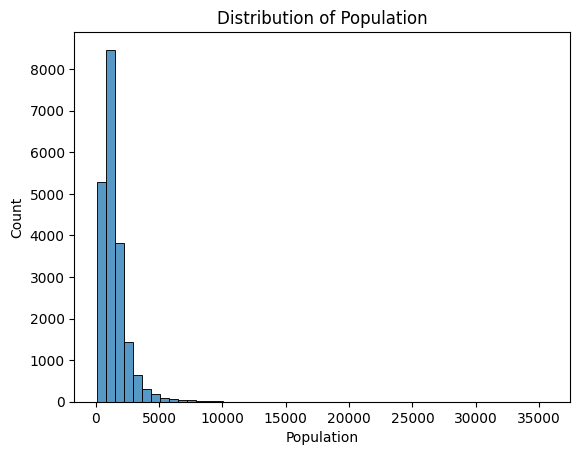

In [28]:
# Show histogram of population
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['population'], bins=50)
plt.title('Distribution of Population')
plt.xlabel('Population')
plt.ylabel('Count')
plt.show()

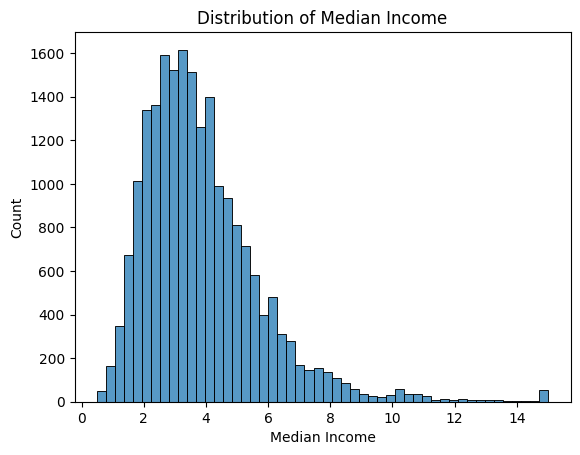

In [17]:
# Show histograph of median income
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['median_income'], bins=50)
plt.title('Distribution of Median Income')
plt.xlabel('Median Income')
plt.ylabel('Count')
plt.show()

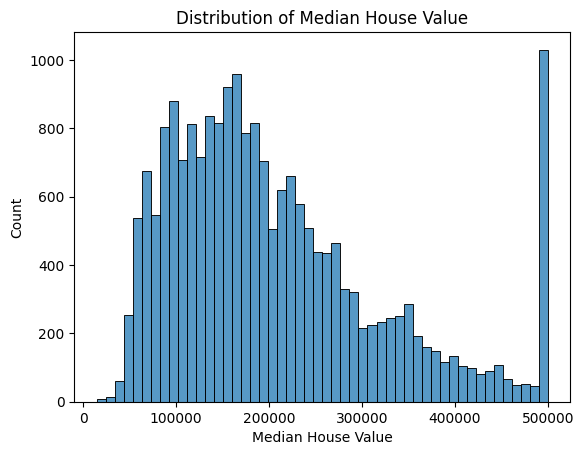

In [16]:
# Show histogram of median_house_value
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['median_house_value'], bins=50)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Count')
plt.show()

## 4. Running the Analysis

We will not use statsmodels to run an OLS regression.

In [ ]:
# Predict median house value
import statsmodels.api as sm
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.535
Model:                            OLS   Adj. R-squared:                  0.535
Method:                 Least Squares   F-statistic:                     5872.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:55:37   Log-Likelihood:            -2.5896e+05
No. Observations:               20406   AIC:                         5.179e+05
Df Residuals:                   20401   BIC:                         5.180e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -2.391e+04   2224